# Transforming the Data from Non-Stationary to Stationary

In [74]:
# import dependencies
import torch.nn as nn
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import tsfeatures as tsf
from sklearn.preprocessing import RobustScaler
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from dataset_preparation import split_data, create_sequences_np
import model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from helper_func import evaluate_model
import pickle

In [21]:
# import the dataset
data = pd.read_csv("./data.csv", parse_dates=['Date'])
# set the index of data_sta to date
data = data.set_index('Date')
data.head()

,y,High,Low,Open,Volume,unique_id,Rolling_Mean_30,Month,day_of_week,quarter,...,month_cos,quarter_sin,quarter_cos,lag_1_y,lag_7_y,lag1_volume,daily_returns,volatility_30,hl_spread,rsi_14
Date,,,,,,,,,,,,,,,,,,,,,
2014-02-18,3.237549,3.246884,3.211409,3.230080,9163500,1,3.153467,2,1,0,...,0.5,0.0,1.0,3.185269,3.084446,20059500.0,-0.008139,0.021711,0.063481,59.161082
2014-02-19,3.187137,3.220744,3.177801,3.194605,13277000,1,3.154462,2,2,0,...,0.5,0.0,1.0,3.237549,3.140459,9163500.0,0.016413,0.021916,0.035475,59.956705
2014-02-20,3.205807,3.215143,3.170332,3.192738,8962000,1,3.153031,2,3,0,...,0.5,0.0,1.0,3.187137,3.114320,13277000.0,-0.015571,0.022073,0.042943,61.283166
2014-02-21,3.196472,3.235682,3.196472,3.218878,7017500,1,3.152097,2,4,0,...,0.5,0.0,1.0,3.205807,3.194605,8962000.0,0.005858,0.022100,0.044810,61.453710
2014-02-24,3.248751,3.263688,3.233814,3.248751,9817000,1,3.145065,2,0,0,...,0.5,0.0,1.0,3.196472,3.233814,7017500.0,-0.002912,0.019631,0.039209,66.270763


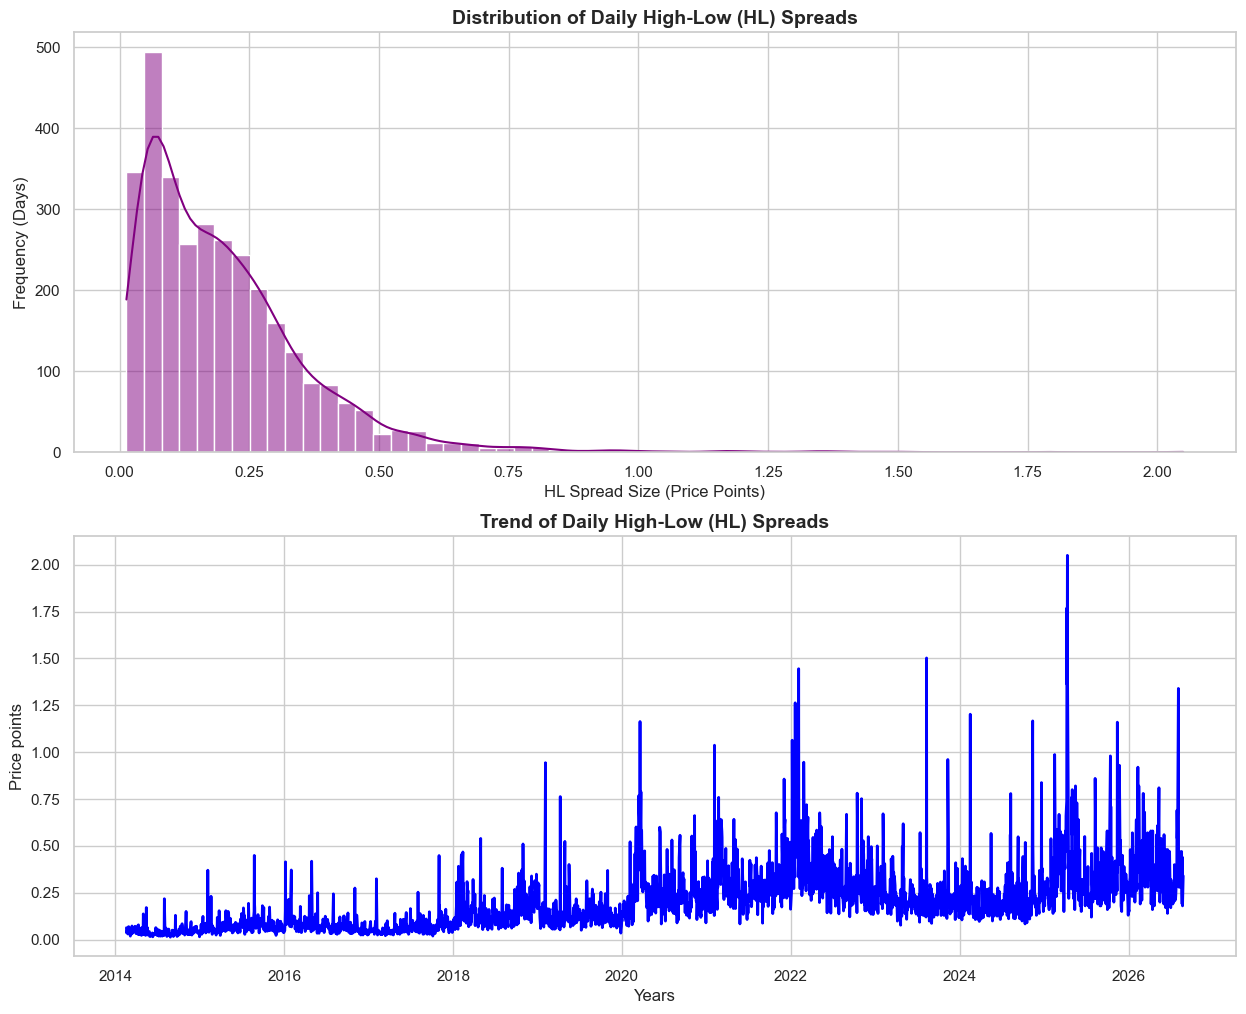

In [22]:
# plot the high-low spread distribution
fig, axes = plt.subplots(2,1, figsize=(15, 12))
sns.set(style="whitegrid")

sns.histplot(data['hl_spread'], bins=60, color='purple', kde=True, ax=axes[0])
sns.lineplot(x=data.index, y=data['hl_spread'], color='blue', ax=axes[1], linewidth=2, linestyle='solid')

axes[0].set_title("Distribution of Daily High-Low (HL) Spreads", fontsize=14, fontweight="bold")
axes[0].set_xlabel("HL Spread Size (Price Points)", fontsize=12)
axes[0].set_ylabel("Frequency (Days)", fontsize=12)

axes[1].set_title('Trend of Daily High-Low (HL) Spreads', fontsize=14, fontweight="bold")
axes[1].set_xlabel("Years", fontsize=12)
axes[1].set_ylabel("Price points", fontsize=12)

plt.show()

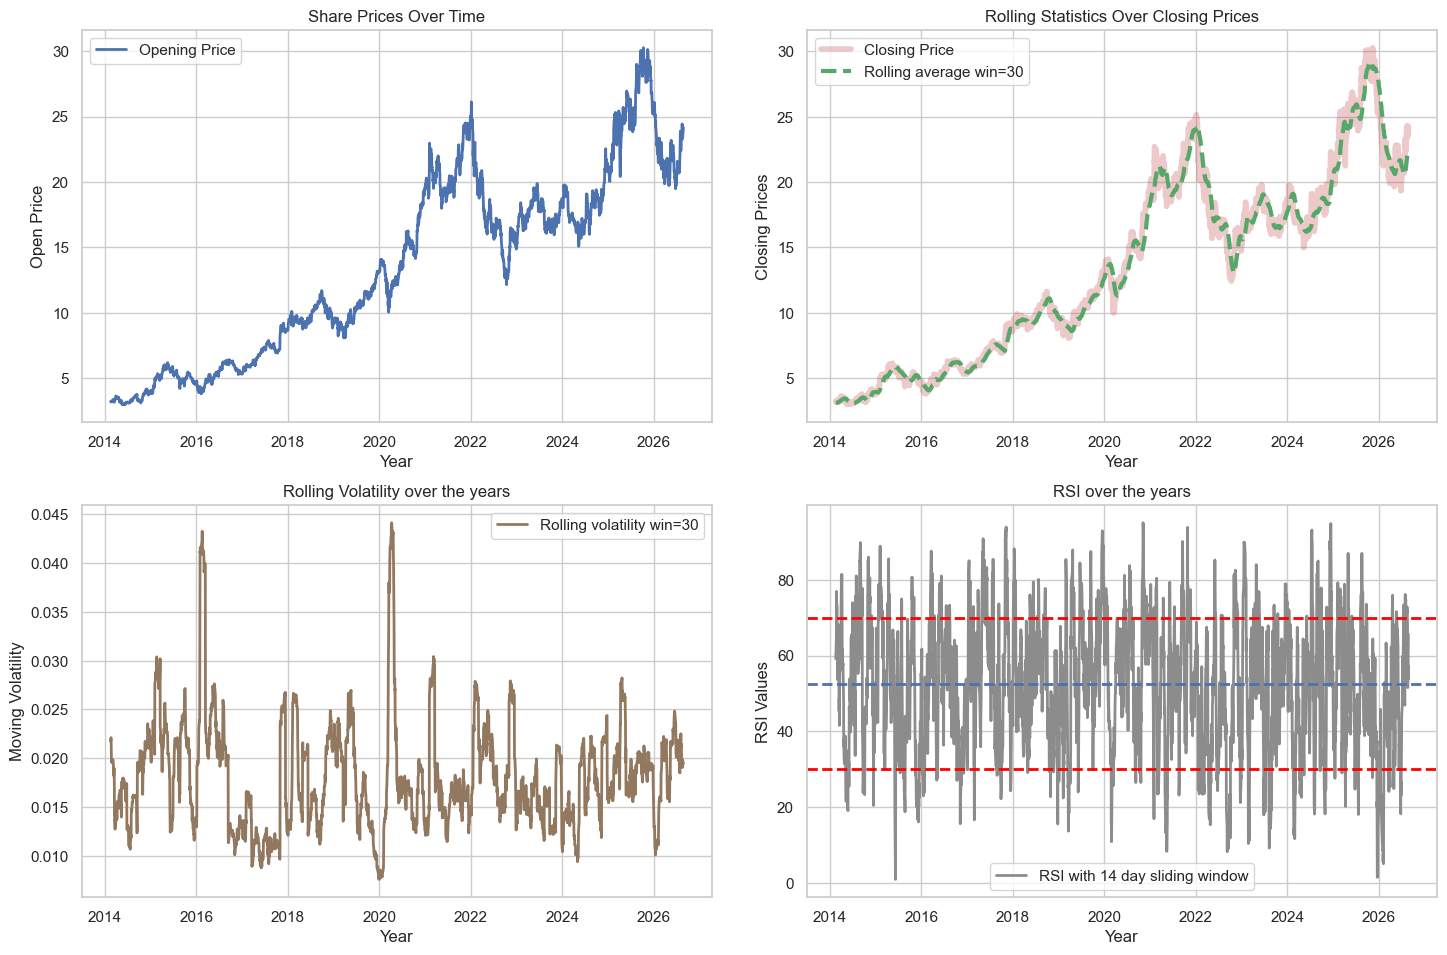

In [23]:
# plot and check for trends/seasonality in the features to determine which features need to be transformed
plt.rc('figure', figsize=(15, 10))
fig, axes = plt.subplots(2, 2, gridspec_kw={'height_ratios': [2, 2]})

# define color pallette
colors = list(sns.color_palette())

fig.tight_layout(pad=3)
sns.set(style="whitegrid") 

# prices plots
sns.lineplot(x=data.index, y=data['Open'], label='Opening Price', color=colors[0], ax=axes[0, 0], linewidth=2)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Open Price')
axes[0, 0].set_title('Share Prices Over Time')

# rolling stats plots
sns.lineplot(x=data.index, y=data.y, label='Closing Price', color=colors[3], alpha=0.3, linewidth=4, ax=axes[0, 1])
sns.lineplot(x=data.index, y=data['Rolling_Mean_30'], label='Rolling average win=30', color=colors[2], ax=axes[0,1], linewidth=3, linestyle='--')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Closing Prices')
axes[0, 1].set_title('Rolling Statistics Over Closing Prices')

# rolling volatility plots 
sns.lineplot(x=data.index, y=data['volatility_30'], label='Rolling volatility win=30', color=colors[5], ax=axes[1,0], linewidth=2)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Moving Volatility')
axes[1, 0].set_title('Rolling Volatility over the years')

# rsi_14 plots
sns.lineplot(x=data.index, y=data['rsi_14'], label='RSI with 14 day sliding window', color=colors[7], ax=axes[1,1], linewidth=2, linestyle='solid')
axes[1, 1].axhline(y=70, color='red', linewidth=2, linestyle='--')
axes[1, 1].axhline(y=30, color='red', linewidth=2, linestyle='--')
axes[1, 1].axhline(y=data['rsi_14'].mean(), color=colors[0], linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('RSI Values')
axes[1, 1].set_title('RSI over the years')

plt.show()

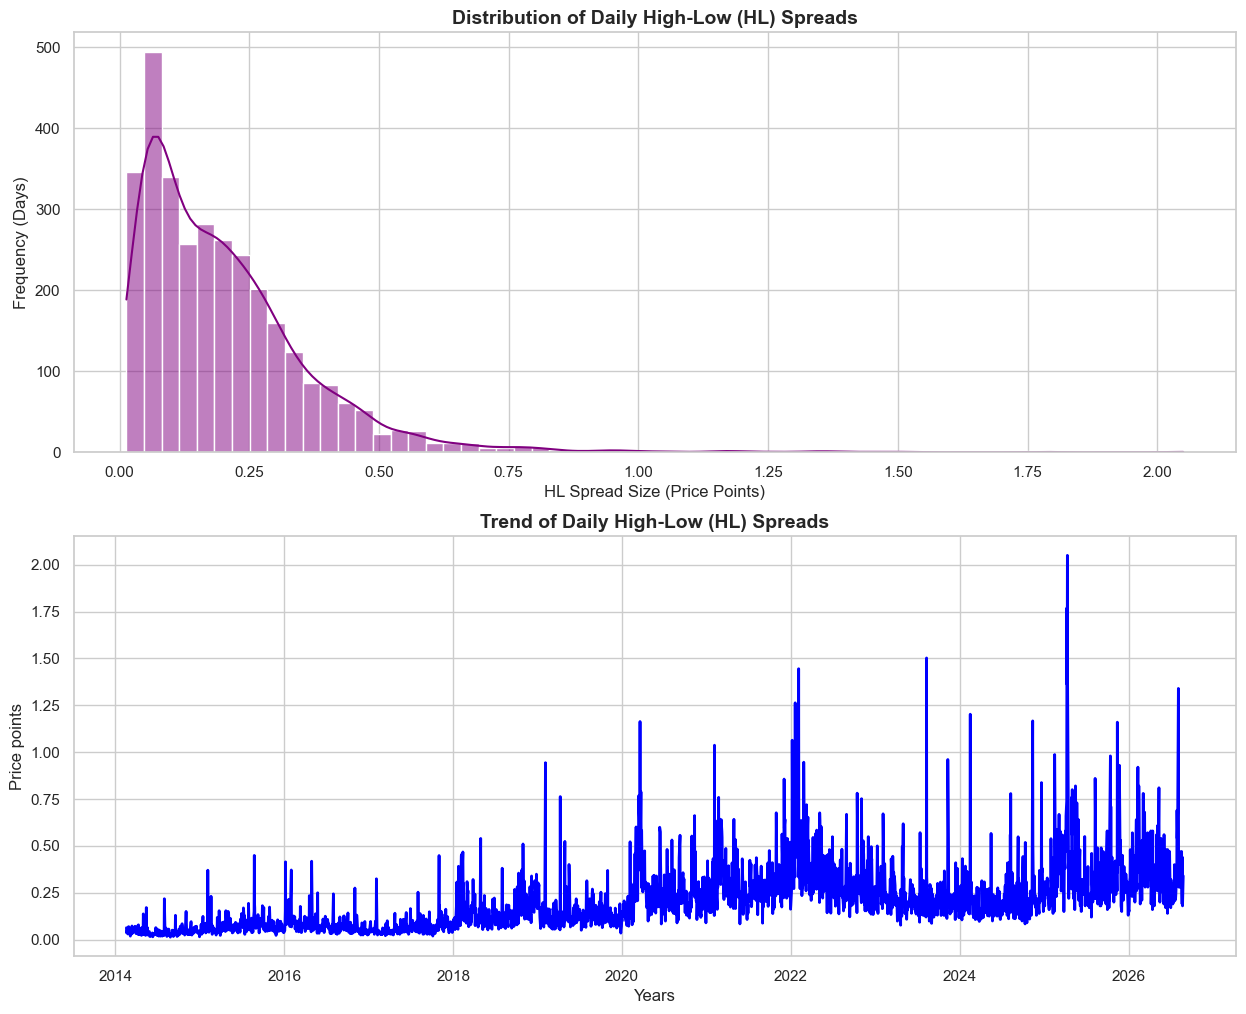

In [24]:
# plot the high-low spread distribution
fig, axes = plt.subplots(2,1, figsize=(15, 12))
sns.set(style="whitegrid")

sns.histplot(data['hl_spread'], bins=60, color='purple', kde=True, ax=axes[0])
sns.lineplot(x=data.index, y=data['hl_spread'], color='blue', ax=axes[1], linewidth=2, linestyle='solid')

axes[0].set_title("Distribution of Daily High-Low (HL) Spreads", fontsize=14, fontweight="bold")
axes[0].set_xlabel("HL Spread Size (Price Points)", fontsize=12)
axes[0].set_ylabel("Frequency (Days)", fontsize=12)

axes[1].set_title('Trend of Daily High-Low (HL) Spreads', fontsize=14, fontweight="bold")
axes[1].set_xlabel("Years", fontsize=12)
axes[1].set_ylabel("Price points", fontsize=12)

plt.show()

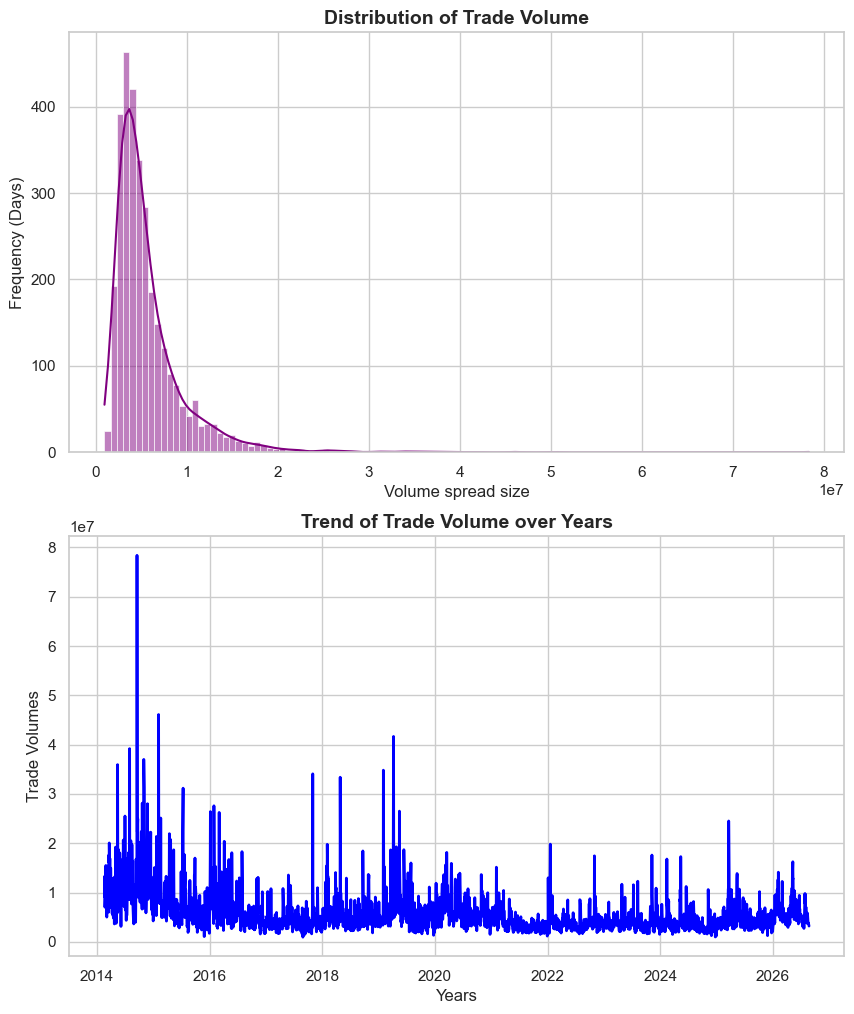

In [25]:
# Trade volume dist plot and line plot
fig, axes = plt.subplots(2,1, figsize=(10, 12))
sns.set(style="whitegrid")

sns.histplot(data['Volume'], color='purple', kde=True, ax=axes[0])
sns.lineplot(x=data.index, y=data['Volume'], color='blue', ax=axes[1], linewidth=2, linestyle='solid')

axes[0].set_title("Distribution of Trade Volume", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Volume spread size", fontsize=12)
axes[0].set_ylabel("Frequency (Days)", fontsize=12)

axes[1].set_title('Trend of Trade Volume over Years', fontsize=14, fontweight="bold")
axes[1].set_xlabel("Years", fontsize=12)
axes[1].set_ylabel("Trade Volumes", fontsize=12)

plt.show()

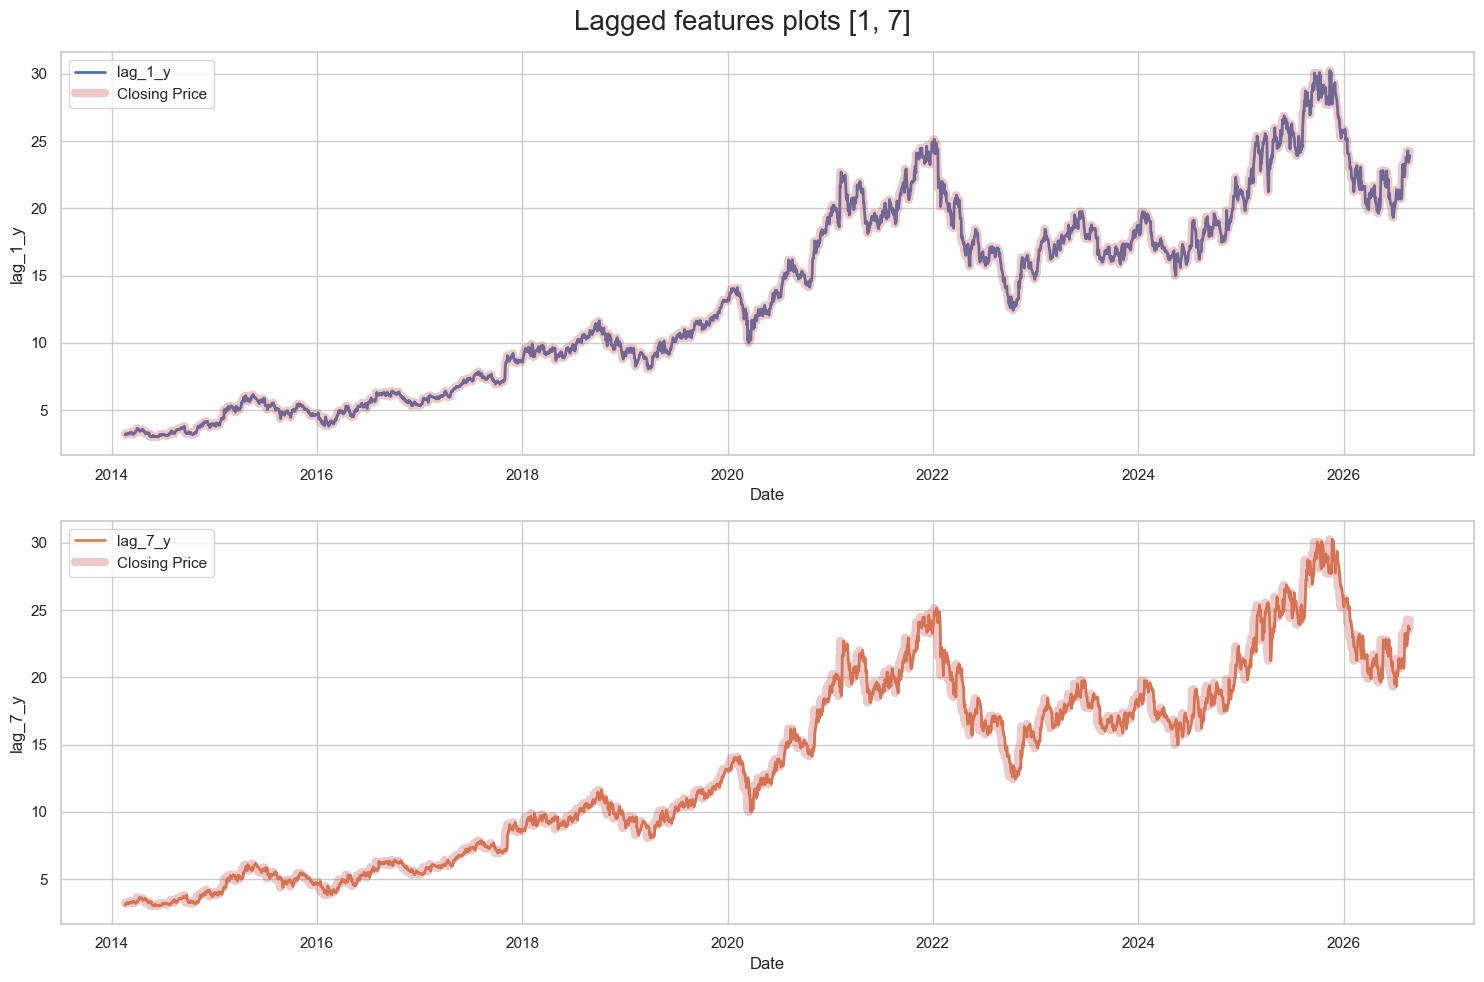

In [26]:
# continued plots for lagged features of target variable
# emphasis - shows that if the original features are non stationary then so are the lagged features

plt.rc('figure', figsize=(15, 10))
fig, axes = plt.subplots(2, 1)
fig.suptitle('Lagged features plots [1, 7]', fontsize=20)

# define color pallette
colors = list(sns.color_palette())

lagged_features = ['lag_1_y', 'lag_7_y']

for i, c in enumerate(lagged_features):
    sns.lineplot(x=data.index, y=data[c], label=c, color=colors[i], linewidth=2, ax=axes[i])
    sns.lineplot(x=data.index, y=data.y, label='Closing Price', color=colors[3], alpha=0.3, linewidth=6, ax=axes[i])

plt.tight_layout()
plt.show()

In [27]:
# create a copy of dataset and transform it to a stationary time series
data_sta = data.copy()

# change the target to predict tommorrows closing price using data up to day t
data_sta['y'] = data_sta['y'].shift(-1)

# define the features which need to be log transformed (fix skewness and bring back to a normal distr)
log_transform = [ 'lag1_volume', 'Volume', 'hl_spread']
# define the features which need to be log differenced (fix exponential upward/downward trend)
log_diff = ['lag_1_y', 'lag_7_y', 'y', 'Rolling_Mean_30', 'Open']
# define the features to perform first-order differencing on
first_order_diff_features = ['volatility_30']

# apply log transformations to fit normal distribution
for c in log_transform:
    data_sta[c] = np.log(data_sta[c])

for c in log_diff:
    data_sta[c] = np.log(data_sta[c]).diff()

for c in first_order_diff_features:
    data_sta[c] = data_sta[c].diff()

# drop nan rows one last time
data_sta = data_sta.dropna()

''' shift(1) puts yesterday's value on today's row.
    shift(-1) puts tomorrow's value on today's row. '''

" shift(1) puts yesterday's value on today's row.\n    shift(-1) puts tomorrow's value on today's row. "

In [28]:
def plot_distributions(features, data, data_sta):
    for feature in features:
        fig, axs = plt.subplots(1, 2, figsize=(15, 5))
        fig.tight_layout(pad=3)

        # Before log transform
        sns.histplot(
            data=data,
            x=feature,
            kde=True,
            ax=axs[0], color='magenta')
        
        axs[0].set_title(f'{feature} — Before transformation')

        # After log transform
        sns.histplot(
            data=data_sta,
            x=feature,
            kde=True,
            ax=axs[1], color=(0.91, 0.33, 0.50, 1)
        )
        axs[1].set_title(f'{feature} — After transformation')

        plt.show()

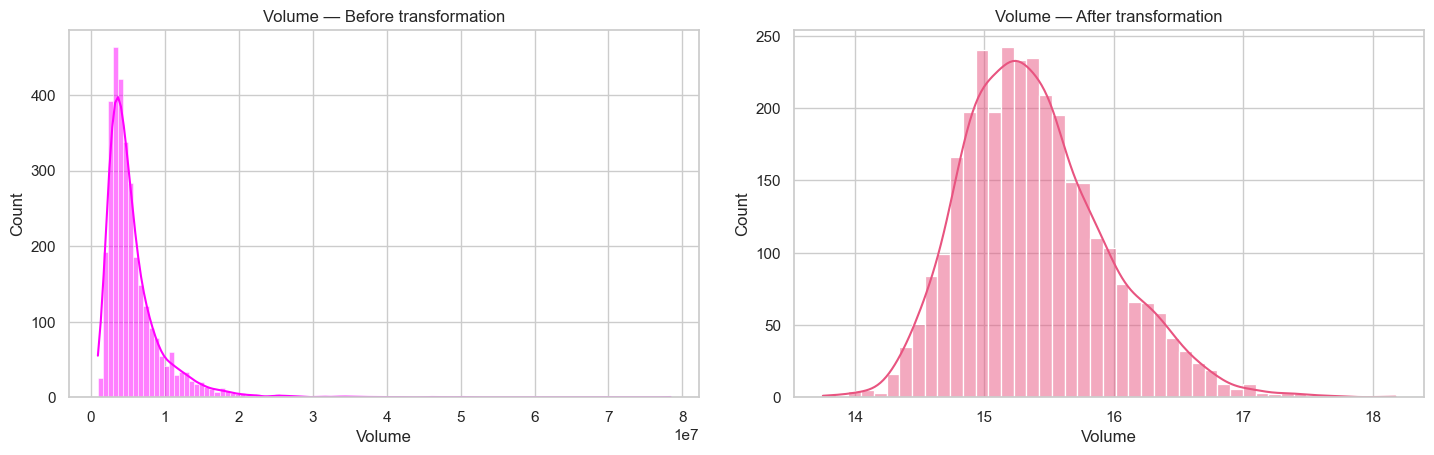

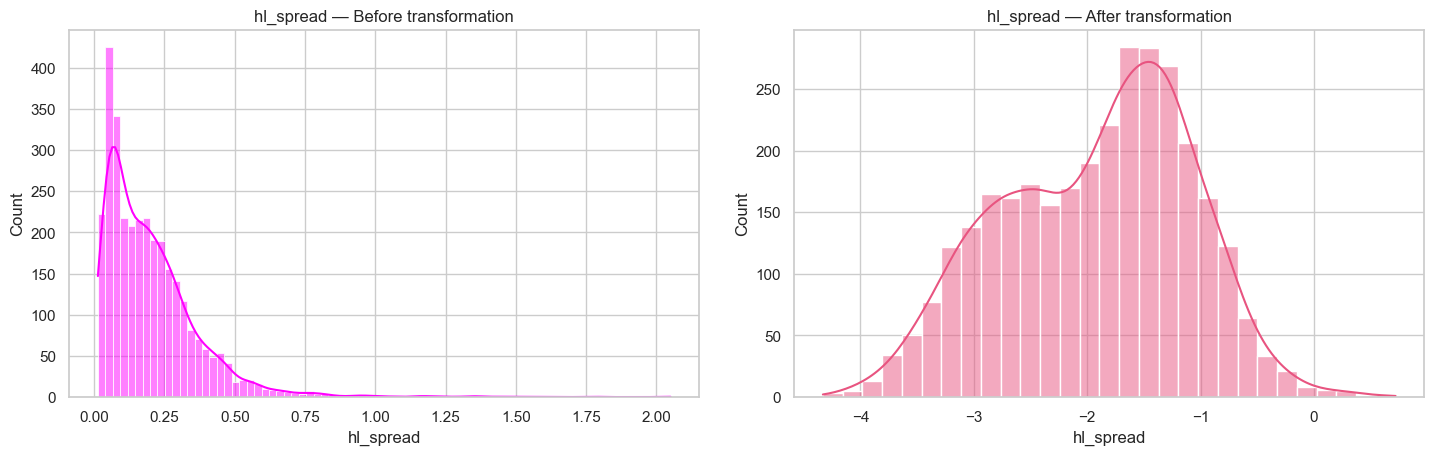

In [29]:
# plot volume and hl_spread distributions before and after
plot_distributions(['Volume', 'hl_spread'], data, data_sta)

In [30]:
def plot_stationarity(feature, data, data_sta, palette="Set2"):
    colors = list(sns.color_palette())

    fig, axs = plt.subplots(2, 1, figsize=(15, 10))
    fig.tight_layout(pad=3)
    
    # Original before transformation
    sns.lineplot(
        x=data.index,
        y=data[feature],
        ax=axs[0],
        color=random.choice(colors),
        label=feature)
    
    axs[0].set_title(f'{feature} — Non-stationary time series')
    axs[0].axhline(
        y=data[feature].mean(),
        color='red',
        linestyle='--')

    # Stationarized after transformation
    sns.lineplot(
        x=data_sta.index,
        y=data_sta[feature],
        ax=axs[1],
        color=random.choice(colors),
        label=feature)
    
    axs[1].set_title(f'{feature} — Log Differenced Stationary time series')
    axs[1].axhline(
        y=data_sta[feature].mean(),
        color='red',
        linestyle='--')

    plt.show()

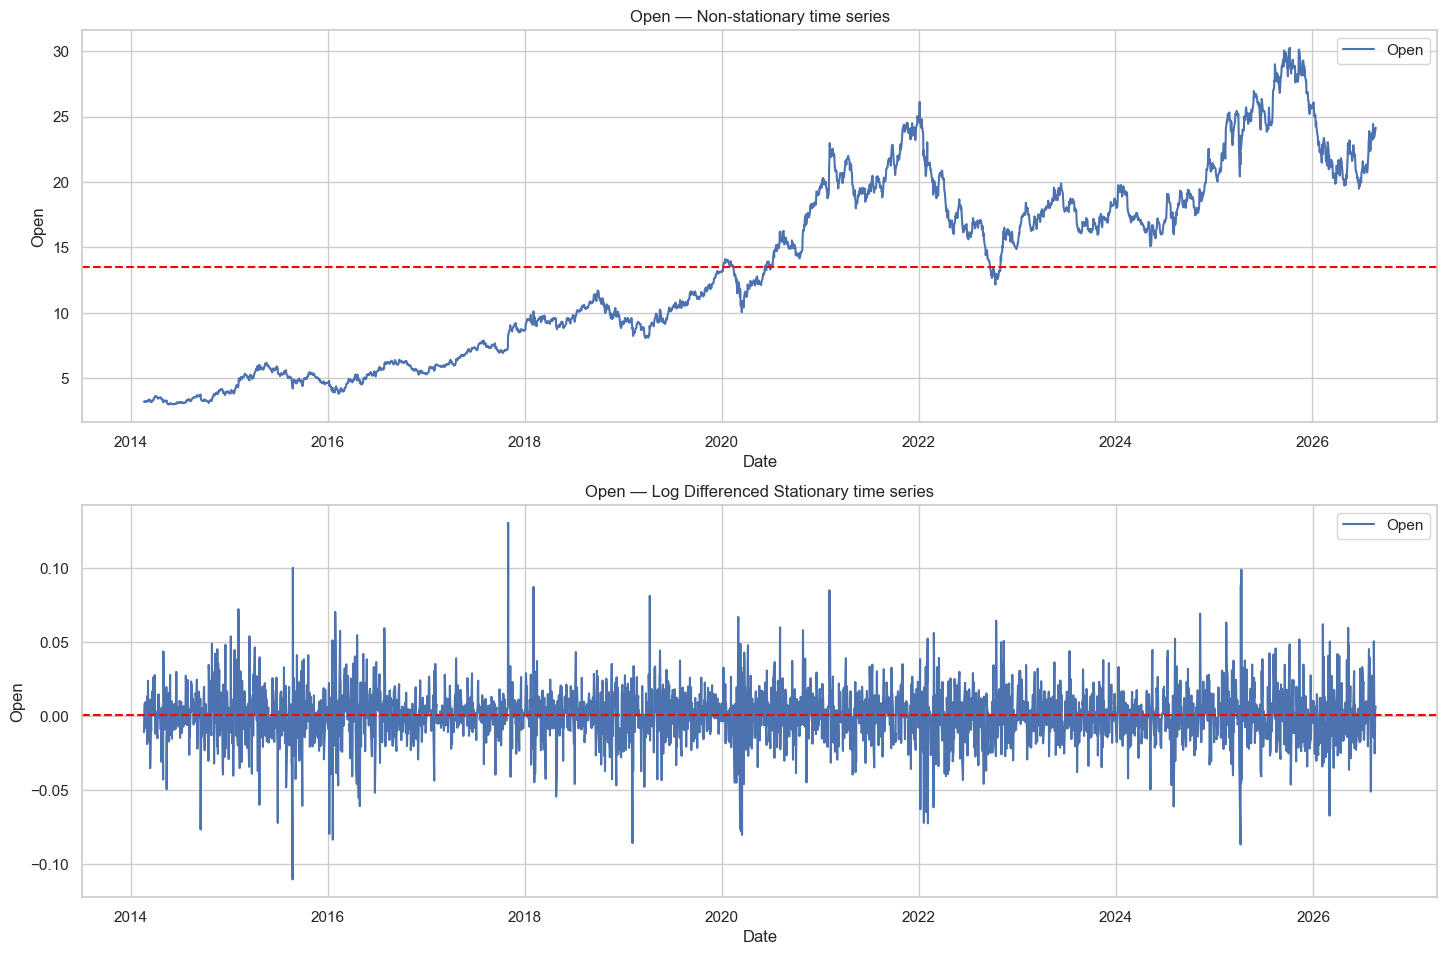

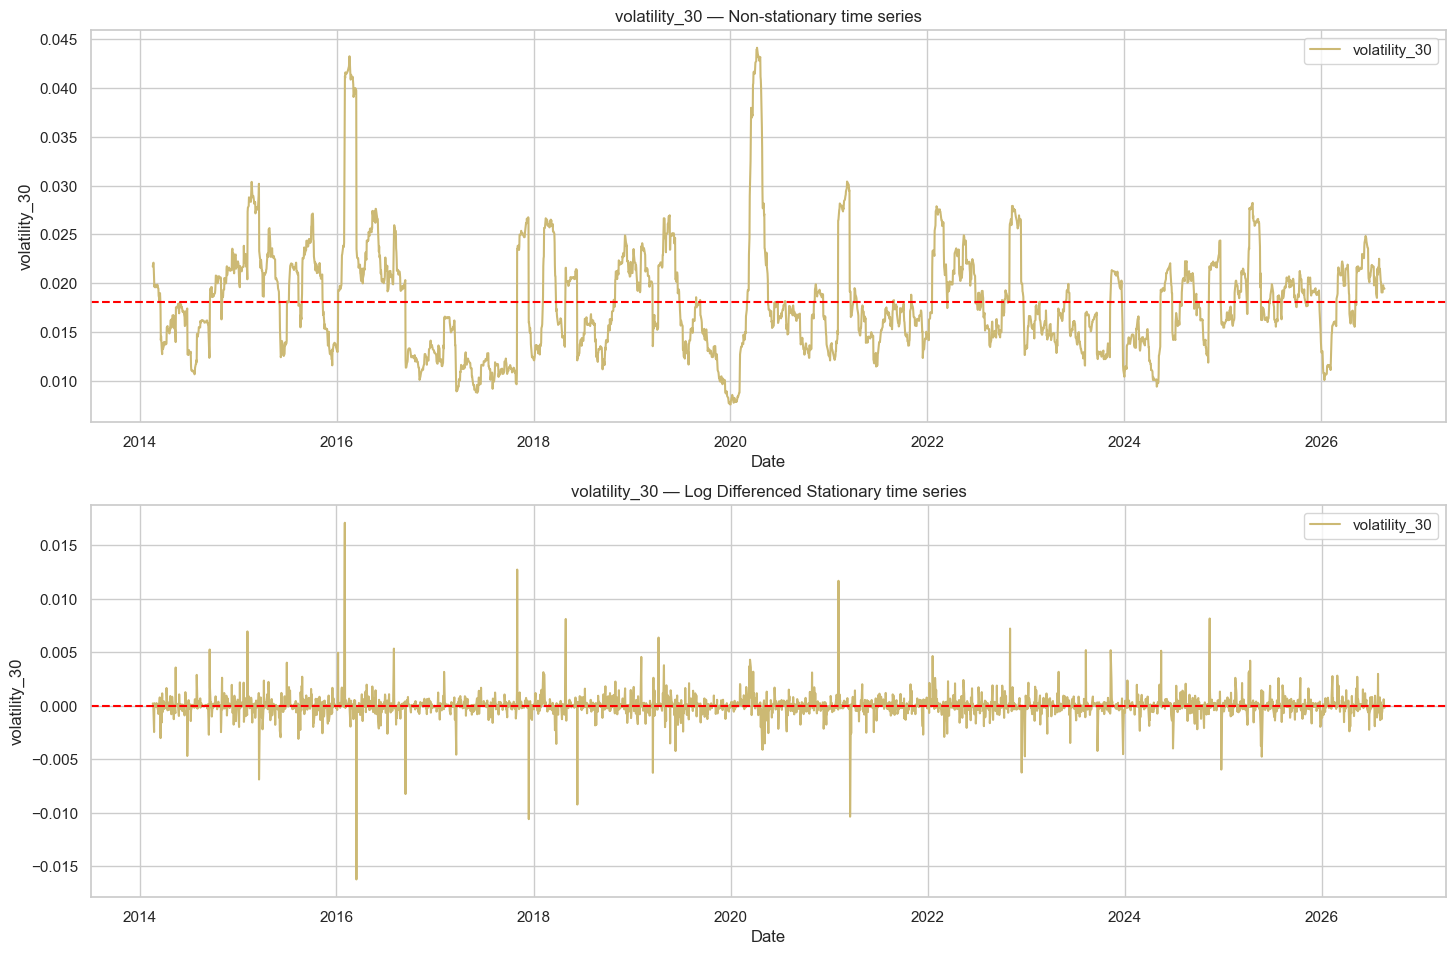

In [31]:
for feature in ['Open', 'volatility_30']:
    plot_stationarity(feature, data, data_sta)

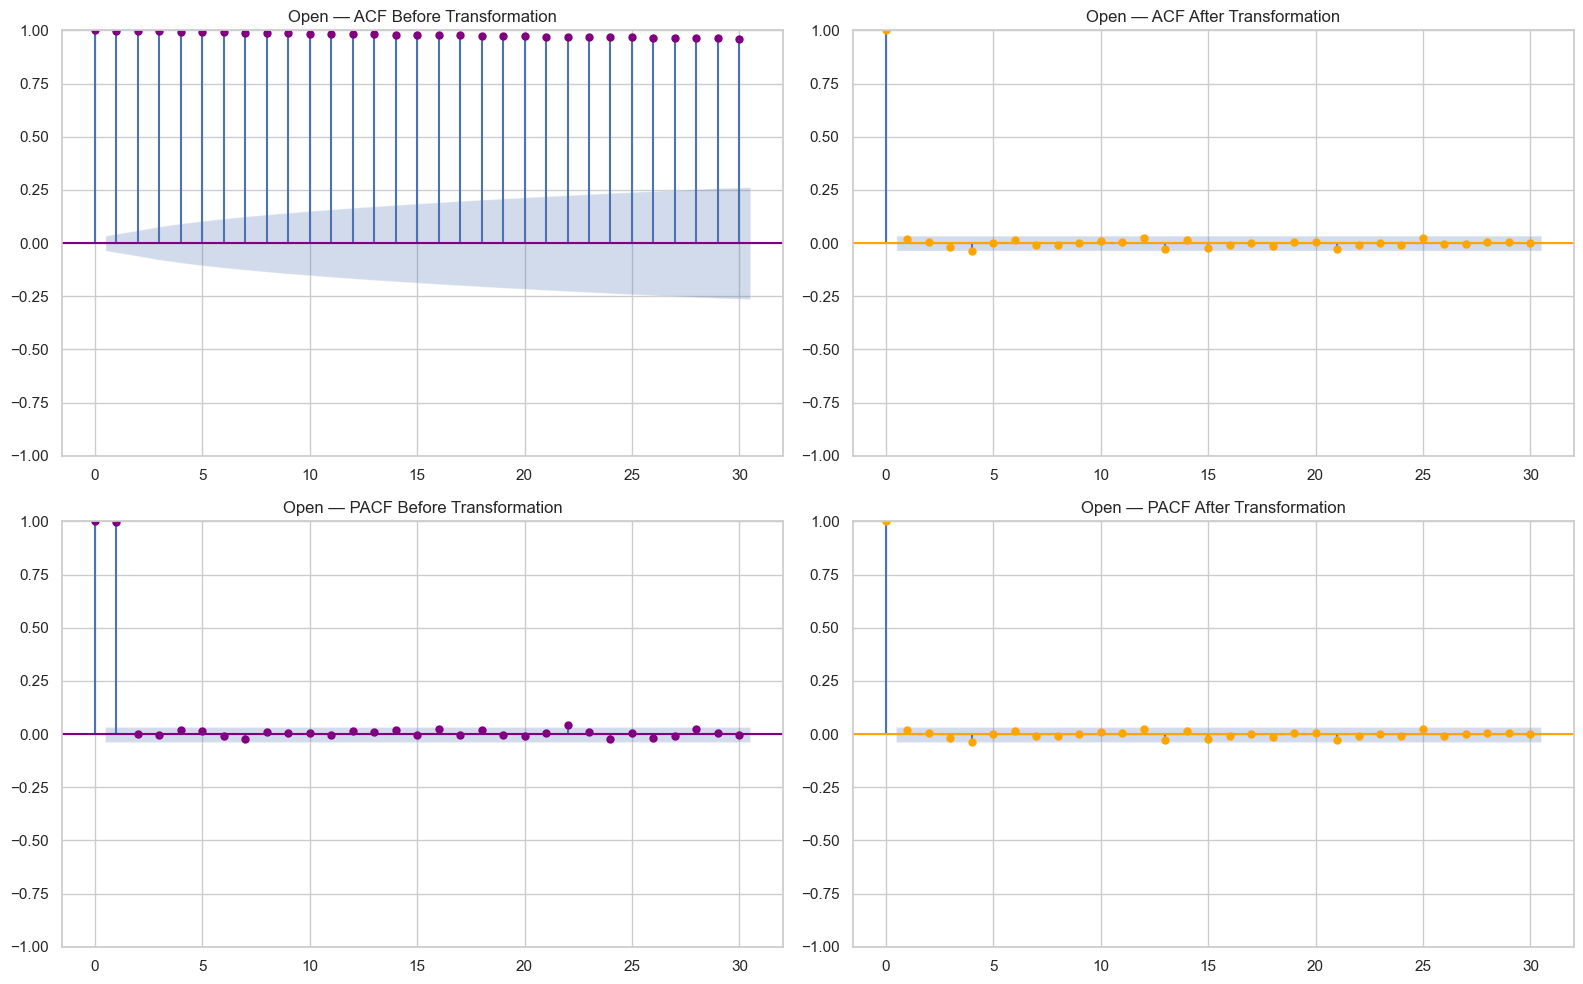

In [32]:
feature = 'Open'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF before
plot_acf(
    data[feature],
    ax=axes[0, 0],
    lags=30,
    color='purple'
)
axes[0, 0].set_title(f'{feature} — ACF Before Transformation')

# ACF after
plot_acf(
    data_sta[feature],
    ax=axes[0, 1],
    lags=30,
    color='orange'
)
axes[0, 1].set_title(f'{feature} — ACF After Transformation')

# PACF before
plot_pacf(
    data[feature],
    ax=axes[1, 0],
    lags=30,
    color='purple'
)
axes[1, 0].set_title(f'{feature} — PACF Before Transformation')

# PACF after
plot_pacf(
    data_sta[feature],
    ax=axes[1, 1],
    lags=30,
    color='orange'
)
axes[1, 1].set_title(f'{feature} — PACF After Transformation')

plt.tight_layout()
plt.show()

In [33]:
# drop the necessary columns 
columns = ['unique_id', 'day_of_week', 'quarter', 'Month', 'High', 'Low']

data_sta = data_sta.drop(columns=columns)
data_sta.columns

Index(['y', 'Open', 'Volume', 'Rolling_Mean_30', 'day_of_week_sin',
       'day_of_week_cos', 'month_sin', 'month_cos', 'quarter_sin',
       'quarter_cos', 'lag_1_y', 'lag_7_y', 'lag1_volume', 'daily_returns',
       'volatility_30', 'hl_spread', 'rsi_14'],
      dtype='object')

In [34]:
# split the dataset 
X_train, y_train, X_val, y_val, X_test, y_test = split_data(data_sta)

Train size: 2202  |  Test size: 472 | Val size 472
Train period: 2014-02-19 to 2022-11-14
Test + val period : 2022-11-15 to 2026-08-21


In [35]:
# scale columns using RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# scale the target value for more stable training
y_scaler = RobustScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
)

y_val_scaled =  y_scaler.transform(
    y_val.to_numpy().reshape(-1, 1)
)

In [36]:
# define sequence len (tunable hyperparameter)
seq_len = 30

X_train_seq, y_train_seq = create_sequences_np(X_train_scaled, y_train_scaled, seq_len)

X_val_ctx = np.concatenate([X_train_scaled[-seq_len:], X_val_scaled])
y_val_ctx = np.concatenate([y_train_scaled[-seq_len:], y_val_scaled])
X_val_seq, y_val_seq = create_sequences_np(X_val_ctx, y_val_ctx, seq_len)

X_test_ctx = np.concatenate([X_val_scaled[-seq_len:], X_test_scaled])
y_test_ctx = np.concatenate([y_val_scaled[-seq_len:], y_test_scaled])
X_test_seq, y_test_seq = create_sequences_np(X_test_ctx, y_test_ctx, seq_len)

In [37]:
# convert sequenced data to tensors 
X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_seq = torch.tensor(y_test_seq, dtype=torch.float32)
X_val_seq = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_seq = torch.tensor(y_val_seq, dtype=torch.float32)

# output data tensor shapes (training examples, seq length, features)
print('x_train.shape = ',X_train_seq.shape)
print('y_train.shape = ', y_train_seq.shape)
print('x_test.shape = ', X_test_seq.shape)
print('y_test.shape = ',y_test_seq.shape)

x_train.shape =  torch.Size([2172, 30, 16])
y_train.shape =  torch.Size([2172, 1])
x_test.shape =  torch.Size([472, 30, 16])
y_test.shape =  torch.Size([472, 1])


In [38]:
# set torch manual seed
torch.manual_seed(1)

# initialize pytorch lightning data module
lstm_dm = model.SONYStocksDataModule(X_train=X_train_seq, y_train=y_train_seq,
                             X_test=X_test_seq, y_test=y_test_seq, batch_size=64, X_val=X_val_seq
                              , y_val = y_val_seq)

In [39]:
# define model checkpoint save the best validation result out of every epoch per model 
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

if torch.mps.is_available():
    trainer = pl.Trainer(max_epochs=200, accelerator='mps', devices=1, callbacks=[checkpoint], enable_progress_bar=False, default_root_dir="lightning_logs_sta/")
elif torch.cuda.is_available():
    trainer = pl.Trainer(max_epochs=200, accelerator='cuda', devices=1, callbacks=[checkpoint], default_root_dir="lightning_logs_sta/")
else:
    trainer = pl.Trainer(max_epochs=200, callbacks=[checkpoint], default_root_dir="lightning_logs_sta/")

        
# fit the trainer to the dm for each of the configured models
trainer.fit(model=model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=128, n_layers=1), datamodule=lstm_dm)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ RegressionLSTM │ 74.9 K │ train │     0 │
│ 1 │ criterion │ MSELoss        │      0 │ train │     0 │
└───┴───────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 74.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 74.9 K                                                                                               
Total estimated model params size (MB): 0.300                                                                      
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=200` reached.


In [65]:
# Generate predictions using trainer.predict
y_test_true_lstm, y_test_pred_lstm = evaluate_model(model=model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=128, n_layers=1), instance=model, 
                                                           evaluate=False, predict=True, ckpt=checkpoint, 
                                                    y_scaler=y_scaler, 
                                                              shape=X_train.shape[-1], trainer=trainer, X_val_seq=None, y_val_seq=None)


y_test_pred_lstm = y_scaler.inverse_transform(preds)
y_test_true_lstm = y_scaler.inverse_transform(y_test_seq.numpy())

rmse_lstm = np.sqrt(mean_squared_error(y_test_true_lstm, y_test_pred_lstm))
mae_lstm = mean_absolute_error(y_test_true_lstm, y_test_pred_lstm)
r2_lstm = r2_score(y_test_true_lstm, y_test_pred_lstm)

print(f"LSTM (best ckpt) | RMSE: {rmse_lstm:.3f} | MAE: {mae_lstm:.3f} | R2: {r2_lstm:.4f}")

LSTM (best ckpt) | RMSE: 0.020 | MAE: 0.015 | R2: -0.0329


In [71]:
# load lightning logs tensor board 
%load_ext tensorboard
%tensorboard --logdir './lightning_logs_sta/'

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with -11).

In [52]:
# train on a baseline linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)

y_test_pred_scaled = lr.predict(X_test_scaled).reshape(-1, 1)

# invert scaling so error is in real log-return units, comparable to the numbers you pasted
y_test_true = y_scaler.inverse_transform(y_test_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)
print(f"Linear Regression | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.4f}")

Linear Regression | RMSE: 0.019 | MAE: 0.014 | R2: -0.0149


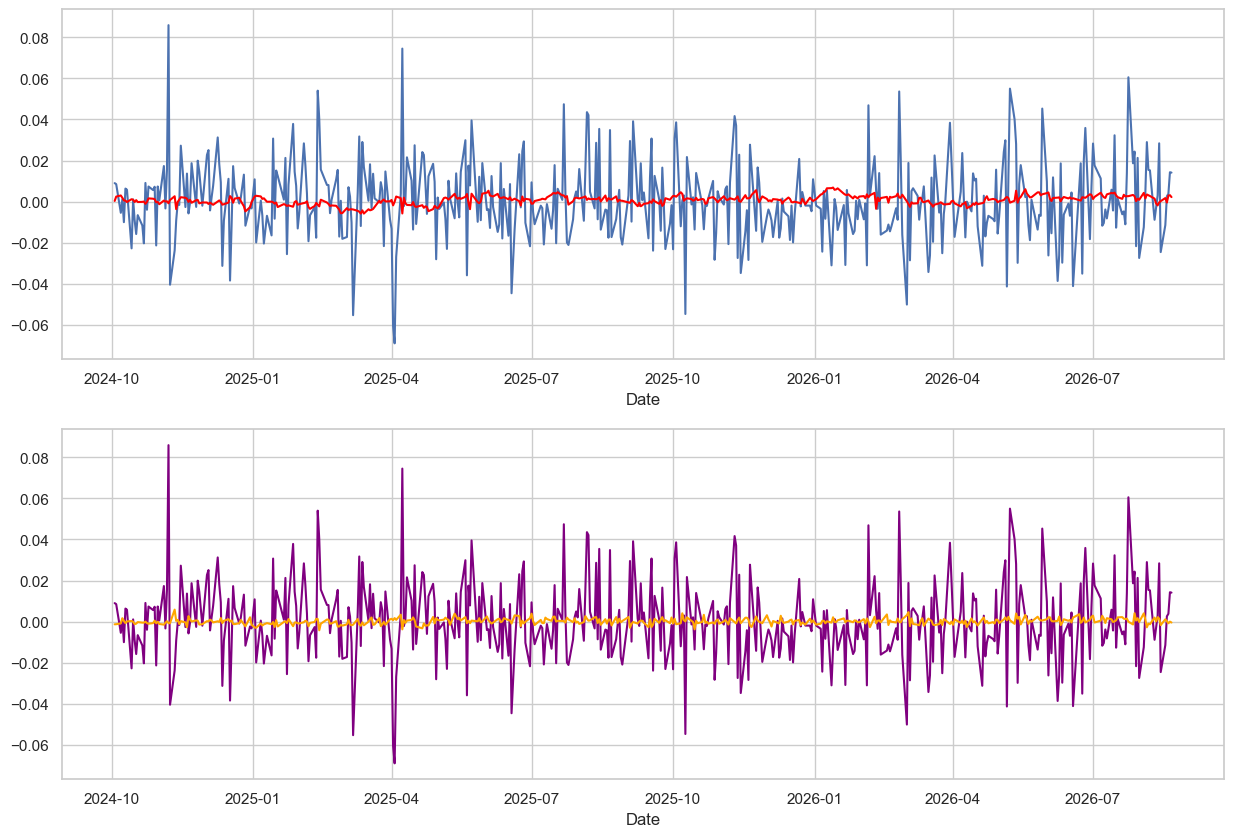

In [53]:
# plot overlays of both the linear regression model, with target values and predictions and the best lstm model config

fig, ax = plt.subplots(2,1, figsize=(15, 10))

sns.lineplot(x=data_sta.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_true_lstm.reshape(y_test_true_lstm.shape[0]), ax=ax[0])
sns.lineplot(x=data_sta.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_pred_lstm.reshape(y_test_pred_lstm.shape[0]), ax=ax[0], color='red')

sns.lineplot(x=data_sta.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_true.reshape(y_test_true.shape[0]), ax=ax[1], color='purple')
sns.lineplot(x=data_sta.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_pred.reshape(y_test_pred.shape[0]), ax=ax[1], color='orange')
plt.show()

In [72]:
# save the lstm model to the current directory
PATH = './lstm_stationary.pt'
torch.save(model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=128, n_layers=1).state_dict(), PATH)

In [75]:
# save linear regressor model using pickle
with open('./linear_regressor_stationary.pkl','wb') as f:
    pickle.dump(lr,f)